## 1. Imports & Configuration

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# WordCloud
from wordcloud import WordCloud

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0
GPU available: False


## 2. Load & Explore the Dataset

In [15]:
df = pd.read_csv('../datasets/book_review/Book_review.csv')
print("Shape:", df.shape)
df.head(3)

Shape: (12000, 4)


,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!


In [16]:
# Basic info
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nRating distribution:\n", df['rating'].value_counts().sort_index())

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  12000 non-null  int64
 1   rating      12000 non-null  int64
 2   reviewText  12000 non-null  str  
 3   summary     11998 non-null  str  
dtypes: int64(2), str(2)
memory usage: 7.5 MB
None

Missing values:
 Unnamed: 0    0
rating        0
reviewText    0
summary       2
dtype: int64

Rating distribution:
 rating
1    2000
2    2000
3    2000
4    3000
5    3000
Name: count, dtype: int64


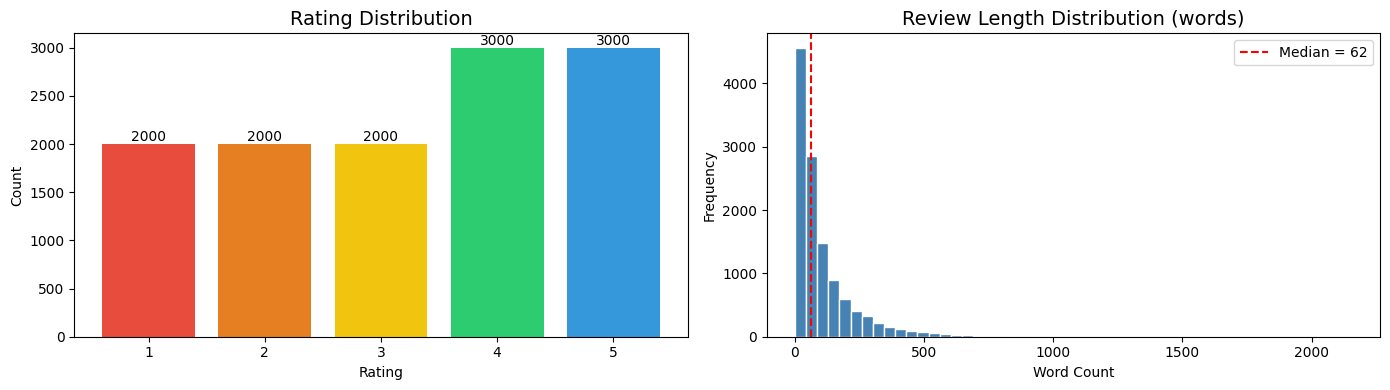

Avg review length: 109.2 words
95th percentile length: 362 words


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rating distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
axes[0].set_title('Rating Distribution', fontsize=14)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
for i, v in enumerate(rating_counts.values):
    axes[0].text(i + 1, v + 30, str(v), ha='center', fontsize=10)

# Review length distribution
df['review_length'] = df['reviewText'].astype(str).apply(lambda x: len(x.split()))
axes[1].hist(df['review_length'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Review Length Distribution (words)', fontsize=14)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['review_length'].median(), color='red',
                linestyle='--', label=f"Median = {df['review_length'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Avg review length: {df['review_length'].mean():.1f} words")
print(f"95th percentile length: {np.percentile(df['review_length'], 95):.0f} words")

## 3. Text Preprocessing

In [18]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOP_WORDS = set(stopwords.words('english'))

negation_words = {'not', 'no', 'nor', 'never'}

STOP_WORDS = STOP_WORDS - negation_words

lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "cannot",
    "won't": "will not",
    "isn't": "is not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "wouldn't": "would not",
    "couldn't": "could not",
    "shouldn't": "should not",
    "i'm": "i am",
    "i've": "i have",
    "i'll": "i will",
    "i'd": "i would",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "they're": "they are",
    "we're": "we are",
    "you're": "you are",
    "he's": "he is",
    "she's": "she is",
    "let's": "let us",
}

def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text

def clean_text(text):

    text = str(text).lower()

    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'@\w+|#\w+', '', text)

    text = re.sub(r'[^a-zA-Z\s!?.,]', ' ', text)

    tokens = text.split()

    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in STOP_WORDS and len(w) > 1
    ]

    return ' '.join(tokens)

print("Cleaning text...")

df['clean_text'] = df['reviewText'].apply(clean_text)

print("Done!")

Cleaning text...
Done!


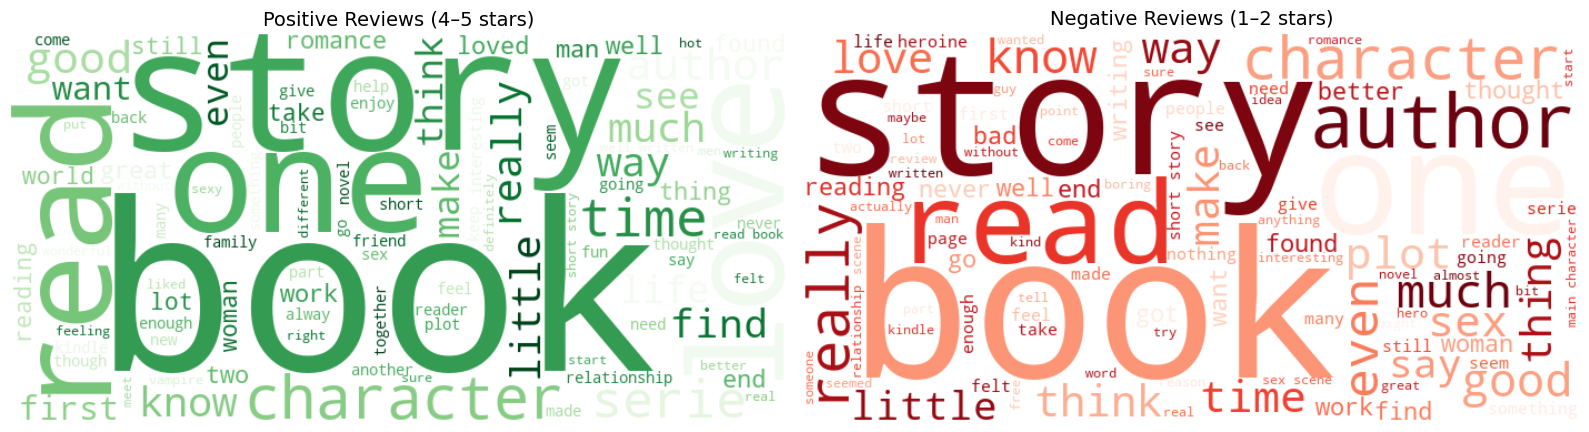

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Positive reviews
pos_text = ' '.join(
    df[df['rating'] >= 4]['clean_text'].astype(str).values
)

wc_pos = WordCloud(
    width=700,
    height=350,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(pos_text)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews (4–5 stars)', fontsize=14)
axes[0].axis('off')

# Negative reviews
neg_text = ' '.join(
    df[df['rating'] <= 2]['clean_text'].astype(str).values
)

wc_neg = WordCloud(
    width=700,
    height=350,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(neg_text)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews (1–2 stars)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Tokenization, Padding & Train/Val/Test Split

In [20]:

VOCAB_SIZE = 10000
OOV_TOKEN = '<OOV>'
EMBED_DIM = 64

clean_lengths = df['clean_text'].apply(lambda x: len(x.split()))
print(f"Avg cleaned review length: {clean_lengths.mean():.1f} words")
MAX_LEN = int(np.percentile(clean_lengths, 95))

print(f"Max sequence length (95th pct): {MAX_LEN}")

X = np.array(df['clean_text'].astype(str))
y = np.array(df['rating'].astype(int) - 1)

NUM_CLASSES = 5

# First split
X_train, X_temp, y_train_raw, y_temp_raw = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split (validation + test)
X_val, X_test, y_val_raw, y_test_raw = train_test_split(
    X_temp,
    y_temp_raw,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_raw
)

# One-hot encoding
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_val = to_categorical(y_val_raw, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test_raw, num_classes=NUM_CLASSES)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ── Tokenizer ────────────────────────────────────────────────────────────────
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index

print(f"Vocabulary size (full): {len(word_index)}")

def texts_to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)

    return pad_sequences(
        seqs,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

X_train_pad = texts_to_padded(X_train)
X_val_pad = texts_to_padded(X_val)
X_test_pad = texts_to_padded(X_test)

print(
    f"Padded shape — train: {X_train_pad.shape}, "
    f"val: {X_val_pad.shape}, "
    f"test: {X_test_pad.shape}"
)

Avg cleaned review length: 56.6 words
Max sequence length (95th pct): 190
Train: 8400 | Val: 1800 | Test: 1800
Vocabulary size (full): 24417
Padded shape — train: (8400, 190), val: (1800, 190), test: (1800, 190)


## 5. Helper Functions

In [21]:
def plot_history(history, model_name):
    """Plot training & validation accuracy and loss."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'{model_name} — Accuracy', fontsize=13)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{model_name} — Loss', fontsize=13)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ","_")}_history.png', dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, X_test_pad, y_test, model_name):
    """Print accuracy, classification report, and confusion matrix."""
    y_pred_prob = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred,
                                target_names=[f'Rating {i+1}' for i in range(5)]))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'R{i+1}' for i in range(5)],
                yticklabels=[f'R{i+1}' for i in range(5)])
    plt.title(f'{model_name} — Confusion Matrix', fontsize=13)
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ","_")}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()
    return acc, y_pred, y_true


# Shared callbacks
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=3,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, verbose=1)
    ]

## 6. Model 1 — Simple RNN with Trainable Embedding

In [22]:
EMBED_DIM = 64

model1 = Sequential(name='SimpleRNN_Model')
model1.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
    input_shape=(MAX_LEN,)
))
model1.add(SimpleRNN(128, return_sequences=False))
model1.add(Dropout(0.4))
model1.add(Dense(64, activation='relu'))
model1.add(Dropout(0.3))
model1.add(Dense(NUM_CLASSES, activation='softmax'))

model1.compile(loss='categorical_crossentropy',
               optimizer='adam',
               metrics=['accuracy'])
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 190, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,285 (2.57 MB)

 Trainable params: 673,285 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
import time
t0 = time.time()

history1 = model1.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=128,
    callbacks=get_callbacks(),
    verbose=1
)

time1 = time.time() - t0
print(f"\nModel 1 training time: {time1/60:.2f} min")

Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.2512 - loss: 1.6047 - val_accuracy: 0.2572 - val_loss: 1.5909 - learning_rate: 0.0010
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.2524 - loss: 1.5935 - val_accuracy: 0.2656 - val_loss: 1.5917 - learning_rate: 0.0010
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.2579 - loss: 1.5850 - val_accuracy: 0.2572 - val_loss: 1.5893 - learning_rate: 0.0010
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.2577 - loss: 1.5820 - val_accuracy: 0.2606 - val_loss: 1.5892 - learning_rate: 0.0010
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.2679 - loss: 1.5723 - val_accuracy: 0.2511 - val_loss: 1.5896 - learning_rate: 0.0010
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.2702 - loss: 1.5666
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.2752 - loss: 1.5625 - val_accu

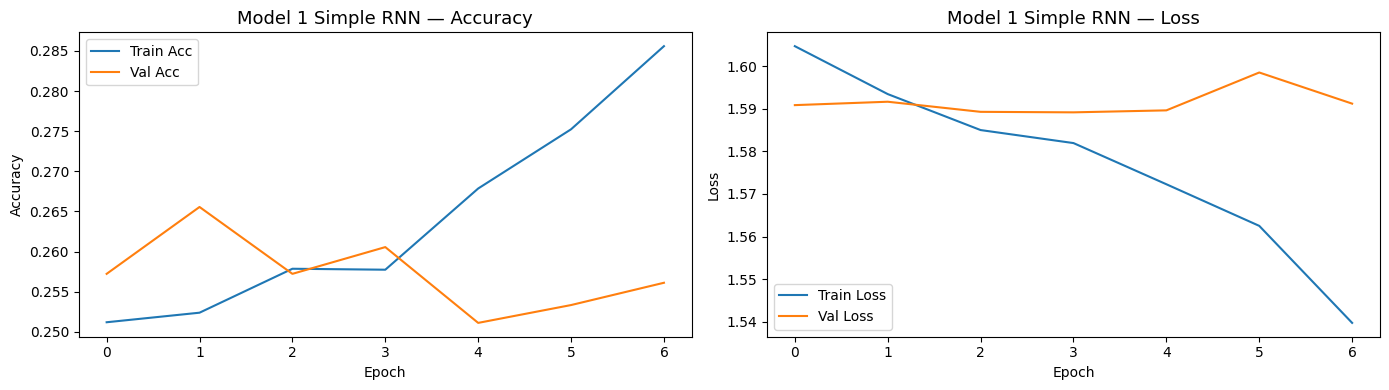


  Model 1 Simple RNN — Test Accuracy: 0.2356
              precision    recall  f1-score   support

    Rating 1       0.00      0.00      0.00       300
    Rating 2       0.33      0.00      0.01       300
    Rating 3       0.00      0.00      0.00       300
    Rating 4       0.22      0.33      0.27       450
    Rating 5       0.24      0.61      0.35       450

    accuracy                           0.24      1800
   macro avg       0.16      0.19      0.12      1800
weighted avg       0.17      0.24      0.15      1800



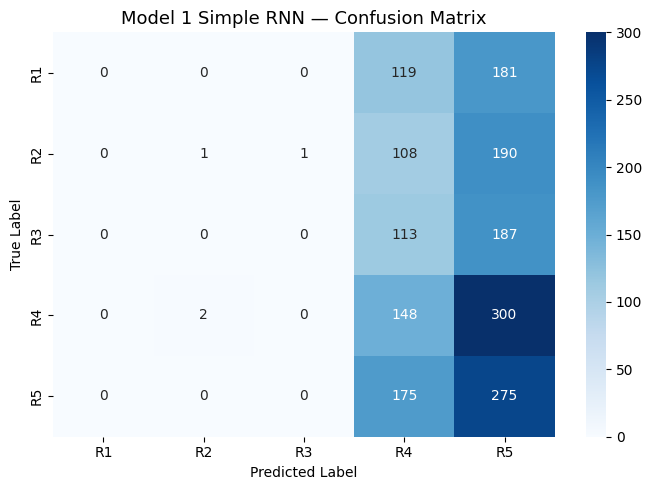

In [24]:
plot_history(history1, 'Model 1 Simple RNN')
acc1, pred1, true1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1 Simple RNN')

## 7. Model 2 — LSTM with Trainable Embedding

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.regularizers import l2

EMBED_DIM = 64

model2 = Sequential(name='Improved_LSTM_Model')

# Input layer
model2.add(Input(shape=(MAX_LEN,)))

# Embedding layer
model2.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        mask_zero=True
    )
)

# LSTM layer
model2.add(
    LSTM(
        64,
        dropout=0.3,
        recurrent_dropout=0.3
    )
)

# Strong dropout
model2.add(Dropout(0.6))

# Dense layer with L2 regularization
model2.add(
    Dense(
        32,
        activation='relu',
        kernel_regularizer=l2(0.001)
    )
)

# Additional dropout
model2.add(Dropout(0.5))

# Output layer
model2.add(Dense(NUM_CLASSES, activation='softmax'))

# Compile
model2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Summary
model2.summary()

Model: "Improved_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 190, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,269 (2.58 MB)

 Trainable params: 675,269 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
t0 = time.time()

history2 = model2.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=128,
    callbacks=get_callbacks(),
    verbose=1
)

time2 = time.time() - t0
print(f"\nModel 2 training time: {time2/60:.2f} min")

Epoch 1/15


66/66 ━━━━━━━━━━━━━━━━━━━━ 24s 287ms/step - accuracy: 0.2496 - loss: 1.6237 - val_accuracy: 0.2533 - val_loss: 1.5716 - learning_rate: 0.0010
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 263ms/step - accuracy: 0.3313 - loss: 1.4573 - val_accuracy: 0.4050 - val_loss: 1.3294 - learning_rate: 0.0010
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 261ms/step - accuracy: 0.3870 - loss: 1.2911 - val_accuracy: 0.4089 - val_loss: 1.2933 - learning_rate: 0.0010
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 256ms/step - accuracy: 0.4224 - loss: 1.2043 - val_accuracy: 0.3972 - val_loss: 1.3154 - learning_rate: 0.0010
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.4387 - loss: 1.1433
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 257ms/step - accuracy: 0.4449 - loss: 1.1402 - val_accuracy: 0.4067 - val_loss: 1.3057 - learning_rate: 0.0010
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 256ms/step - accuracy: 0.4980 - loss: 1.0707 - val_ac

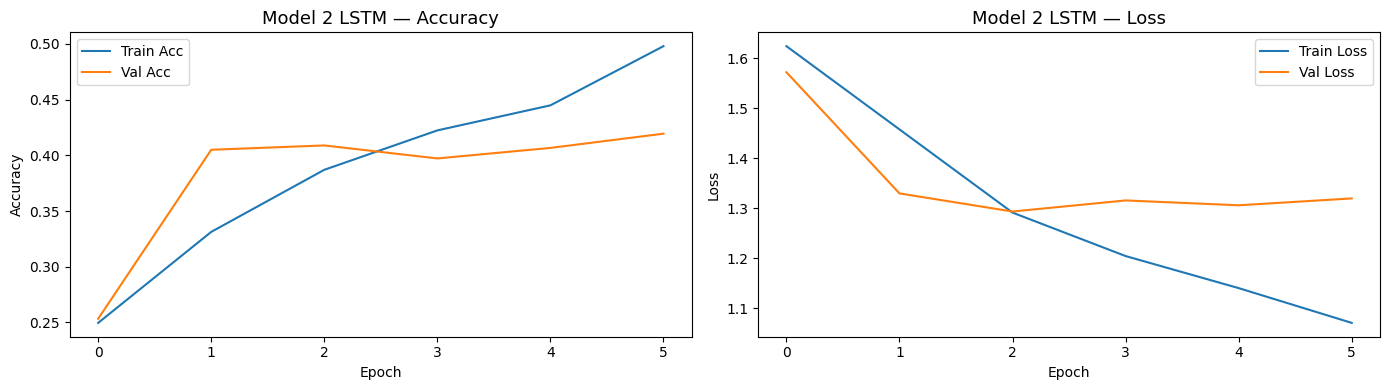


  Model 2 LSTM — Test Accuracy: 0.4117
              precision    recall  f1-score   support

    Rating 1       0.37      0.86      0.52       300
    Rating 2       0.27      0.06      0.10       300
    Rating 3       0.27      0.05      0.08       300
    Rating 4       0.35      0.35      0.35       450
    Rating 5       0.55      0.65      0.60       450

    accuracy                           0.41      1800
   macro avg       0.36      0.39      0.33      1800
weighted avg       0.38      0.41      0.35      1800



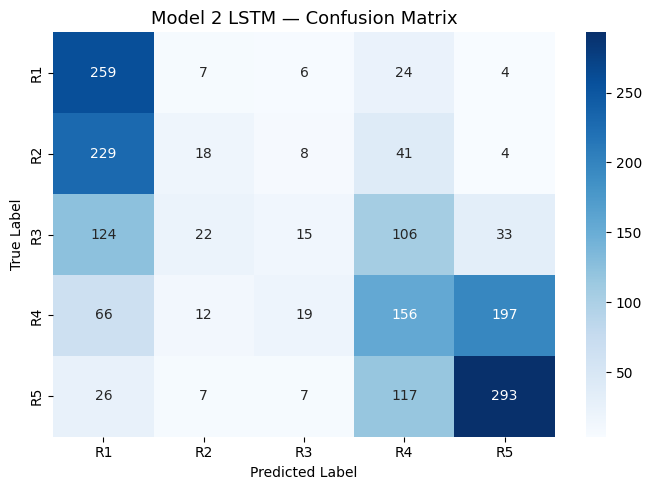

In [27]:
plot_history(history2, 'Model 2 LSTM')
acc2, pred2, true2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2 LSTM')

## 8. Model 3 — LSTM with Pre-trained GloVe (Word2Vec-style) Embeddings

In [28]:
import gensim.downloader as api

print("Loading GloVe embeddings (glove-twitter-100) — ~39 MB ...")
embedding_model = api.load('glove-twitter-100')  
GLOVE_DIM = 100
print("Loaded!")

# Build embedding matrix
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found, not_found = 0, 0

for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1
    else:
        not_found += 1

coverage = found / (found + not_found) * 100
print(f"Words covered by GloVe: {found} / {found+not_found} ({coverage:.1f}%)")

Loading GloVe embeddings (glove-twitter-100) — ~39 MB ...
Loaded!
Words covered by GloVe: 9793 / 9999 (97.9%)


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout
)

model3 = Sequential(name='LSTM_GloVe_Model')

# Explicit input layer
model3.add(Input(shape=(MAX_LEN,)))

# GloVe embedding layer
model3.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=GLOVE_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False,     # frozen pretrained embeddings
        mask_zero=True
    )
)

# First LSTM
model3.add(
    LSTM(
        128,
        return_sequences=True
    )
)

model3.add(Dropout(0.3))

# Second LSTM
model3.add(
    LSTM(
        64,
        return_sequences=False
    )
)

model3.add(Dropout(0.3))

# Dense layer
model3.add(Dense(64, activation='relu'))

model3.add(Dropout(0.2))

# Output layer
model3.add(Dense(NUM_CLASSES, activation='softmax'))

# Compile
model3.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Summary
model3.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 190, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 190, 128)       │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 190, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,171,141 (4.47 MB)

 Trainable params: 171,141 (668.52 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [30]:
t0 = time.time()

history3 = model3.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=128,
    callbacks=get_callbacks(),
    verbose=1
)

time3 = time.time() - t0
print(f"\nModel 3 training time: {time3/60:.2f} min")

Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 34s 443ms/step - accuracy: 0.3171 - loss: 1.4657 - val_accuracy: 0.3728 - val_loss: 1.3622 - learning_rate: 0.0010
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 423ms/step - accuracy: 0.4081 - loss: 1.3178 - val_accuracy: 0.4000 - val_loss: 1.2968 - learning_rate: 0.0010
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 446ms/step - accuracy: 0.4442 - loss: 1.2553 - val_accuracy: 0.4361 - val_loss: 1.2827 - learning_rate: 0.0010
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 471ms/step - accuracy: 0.4663 - loss: 1.2177 - val_accuracy: 0.4156 - val_loss: 1.2639 - learning_rate: 0.0010
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 443ms/step - accuracy: 0.4677 - loss: 1.2031 - val_accuracy: 0.4389 - val_loss: 1.2505 - learning_rate: 0.0010
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 450ms/step - accuracy: 0.4774 - loss: 1.1840 - val_accuracy: 0.4333 - val_loss: 1.2398 - learning_rate: 0.0010
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 439ms/step - accuracy: 0.5007 - loss: 1.

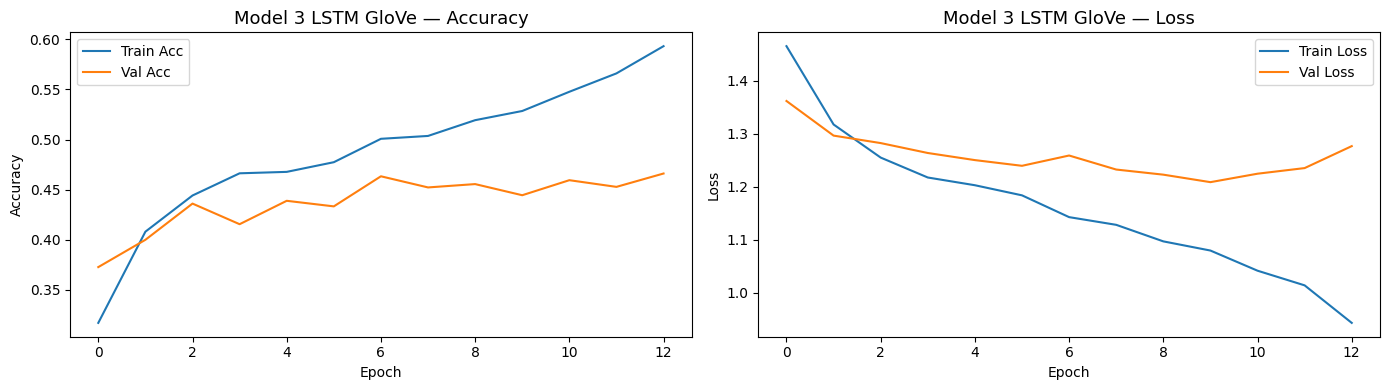


  Model 3 LSTM GloVe — Test Accuracy: 0.4528
              precision    recall  f1-score   support

    Rating 1       0.54      0.53      0.54       300
    Rating 2       0.38      0.34      0.36       300
    Rating 3       0.33      0.37      0.35       300
    Rating 4       0.42      0.50      0.46       450
    Rating 5       0.60      0.48      0.53       450

    accuracy                           0.45      1800
   macro avg       0.45      0.45      0.45      1800
weighted avg       0.46      0.45      0.46      1800



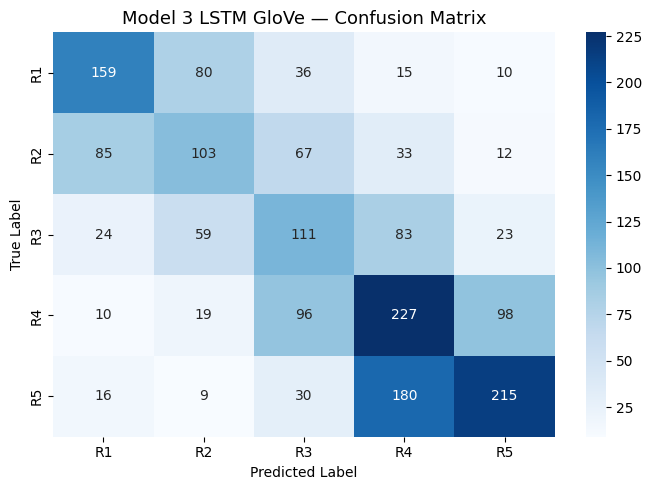

In [37]:
plot_history(history3, 'Model 3 LSTM GloVe')
acc3, pred3, true3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3 LSTM GloVe')

## 9. Comparative Analysis — All Three Models

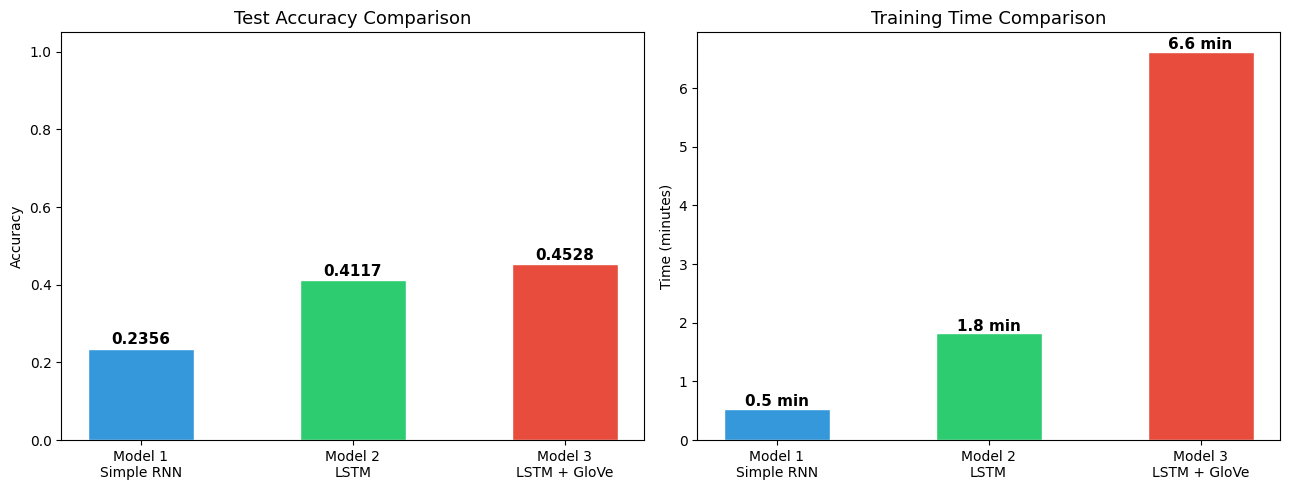

                Model Test Accuracy Training Time (min)
  Model 1\nSimple RNN        0.2356                 0.5
        Model 2\nLSTM        0.4117                 1.8
Model 3\nLSTM + GloVe        0.4528                 6.6


In [38]:
# Accuracy comparison bar chart
model_names  = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM + GloVe']
accuracies   = [acc1, acc2, acc3]
train_times  = [time1/60, time2/60, time3/60]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[0].bar(model_names, accuracies, color=colors, edgecolor='white', width=0.5)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Test Accuracy Comparison', fontsize=13)
axes[0].set_ylabel('Accuracy')

axes[1].bar(model_names, train_times, color=colors, edgecolor='white', width=0.5)
for i, t in enumerate(train_times):
    axes[1].text(i, t + 0.05, f'{t:.1f} min', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Training Time Comparison', fontsize=13)
axes[1].set_ylabel('Time (minutes)')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
summary = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy': [f'{a:.4f}' for a in accuracies],
    'Training Time (min)': [f'{t:.1f}' for t in train_times]
})
print(summary.to_string(index=False))

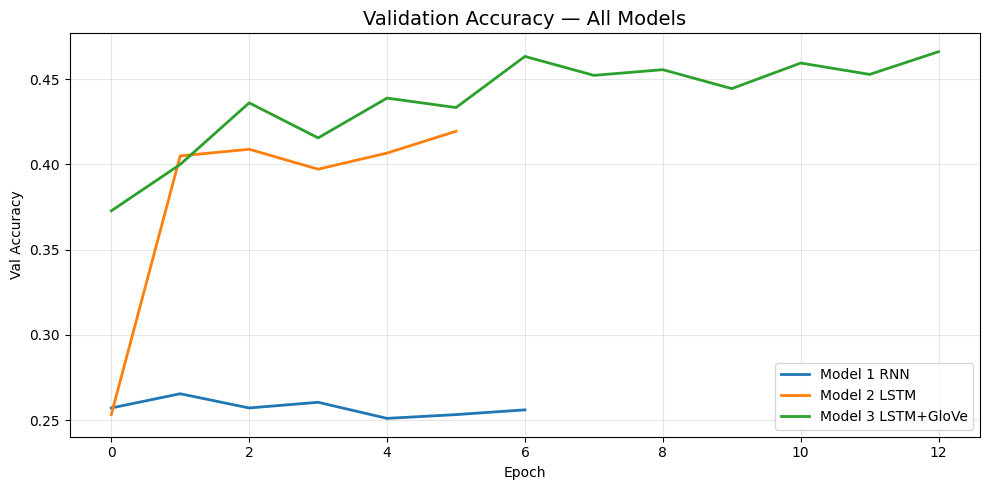

In [39]:
# Overlay val-accuracy curves
plt.figure(figsize=(10, 5))
plt.plot(history1.history['val_accuracy'], label='Model 1 RNN', linewidth=2)
plt.plot(history2.history['val_accuracy'], label='Model 2 LSTM', linewidth=2)
plt.plot(history3.history['val_accuracy'], label='Model 3 LSTM+GloVe', linewidth=2)
plt.title('Validation Accuracy — All Models', fontsize=14)
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('val_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Error Analysis

In [40]:
# Use best model (Model 3 or whichever has highest accuracy)
best_model  = model3
best_preds  = pred3
best_trues  = true3
best_name   = 'Model 3 LSTM+GloVe'

# Get original test texts
_, X_temp_raw, _, _ = train_test_split(X, y, test_size=0.30,
                                        random_state=42, stratify=y)
_, X_test_raw = train_test_split(X_temp_raw, test_size=0.50, random_state=42)

# Find misclassified examples
errors = np.where(best_preds != best_trues)[0]
print(f"Total misclassified by {best_name}: {len(errors)} / {len(best_trues)} "
      f"({len(errors)/len(best_trues)*100:.1f}%)\n")

print("=" * 70)
print("EXAMPLE MISCLASSIFICATIONS")
print("=" * 70)
for i, idx in enumerate(errors[:5]):
    print(f"\nExample {i+1}:")
    # Show cleaned text (truncated)
    print(f"  Text (cleaned): {X_test_raw[idx][:150]}...")
    print(f"  True Rating   : {best_trues[idx] + 1}")
    print(f"  Predicted     : {best_preds[idx] + 1}")
    print(f"  Gap           : {abs(best_trues[idx] - best_preds[idx])} stars")

Total misclassified by Model 3 LSTM+GloVe: 985 / 1800 (54.7%)

EXAMPLE MISCLASSIFICATIONS

Example 1:
  Text (cleaned): written well, though could written better.but going slap cereal box story, might well make quick possible.i not take long get it, plus. cool whole sha...
  True Rating   : 3
  Predicted     : 4
  Gap           : 1 stars

Example 2:
  Text (cleaned): started well fizzled out... may spoiler first chapter interesting. even though premise cliche secretary fall love rich bos book started well. find pov...
  True Rating   : 5
  Predicted     : 4
  Gap           : 1 stars

Example 3:
  Text (cleaned): f. scott fitzgerald great collection marvelous compilation wonderful surprise read curious case benjamin buttons! forgotten tale written fitzgerald! n...
  True Rating   : 5
  Predicted     : 3
  Gap           : 2 stars

Example 4:
  Text (cleaned): short story not purpose. would not recommend reading unless extremely bored. gave not find grammatical error like book read....
  

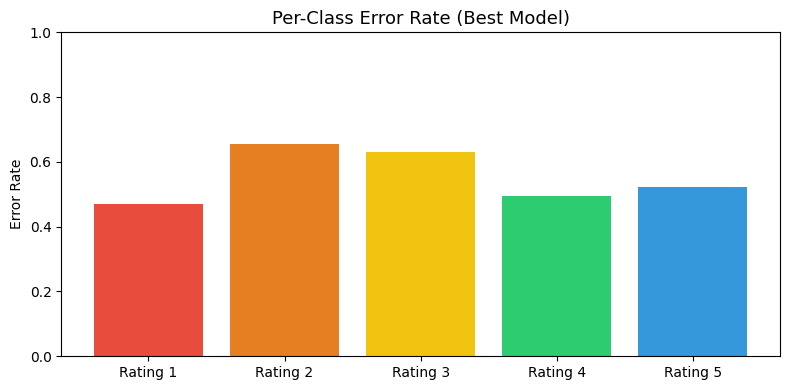

In [41]:
# Per-class error rate
per_class_errors = []
for cls in range(5):
    mask = best_trues == cls
    if mask.sum() == 0:
        per_class_errors.append(0)
        continue
    err_rate = (best_preds[mask] != best_trues[mask]).mean()
    per_class_errors.append(err_rate)

plt.figure(figsize=(8, 4))
plt.bar([f'Rating {i+1}' for i in range(5)], per_class_errors,
        color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
plt.title('Per-Class Error Rate (Best Model)', fontsize=13)
plt.ylabel('Error Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('per_class_error.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
import gradio as gr

STAR_LABELS = {
    0: "⭐ 1 Star — Very Poor",
    1: "⭐⭐ 2 Stars — Poor",
    2: "⭐⭐⭐ 3 Stars — Average",
    3: "⭐⭐⭐⭐ 4 Stars — Good",
    4: "⭐⭐⭐⭐⭐ 5 Stars — Excellent",
}

def predict_rating(review_text: str):
    """Clean, tokenize and predict rating for input review."""
    if not review_text.strip():
        return "Please enter a review text.", {}

    cleaned = clean_text(review_text)
    padded  = texts_to_padded([cleaned])         # shape (1, MAX_LEN)
    probs   = best_model.predict(padded, verbose=0)[0]  # shape (5,)
    pred_class = int(np.argmax(probs))

    label  = STAR_LABELS[pred_class]
    conf   = {STAR_LABELS[i]: float(probs[i]) for i in range(5)}
    return label, conf


demo = gr.Interface(
    fn=predict_rating,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Paste a book review here...",
        label="Book Review"
    ),
    outputs=[
        gr.Textbox(label="Predicted Rating"),
        gr.Label(label="Confidence Scores", num_top_classes=5)
    ],
    title="📚 Book Review Rating Predictor",
    description=(
        "Enter a book review and the model will predict its star rating (1–5). "
        "Powered by LSTM + GloVe embeddings."
    ),
    examples=[
        ["I absolutely loved this book! The characters were vivid and the plot kept me hooked."],
        ["Terrible waste of time. Boring characters and a predictable storyline with no depth."],
        ["An okay read. Nothing special but not bad either. Some good moments."],
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)   # share=True gives a public Colab link

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://fe01c6cfdcf3c46c21.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 12. Summary & Observations

| Model | Architecture | Embedding | Notes |
|-------|-------------|-----------|-------|
| 1 | Simple RNN | Trainable | Fast but struggles with long-range dependencies |
| 2 | 2-layer LSTM | Trainable | Better context capture, handles vanishing gradient |
| 3 | 2-layer LSTM | GloVe (frozen) | Pre-trained semantic knowledge, often best accuracy |

**Key observations:**
- Ratings 1 and 5 are typically easiest to classify (strong sentiment signal).
- Ratings 2–4 are harder to distinguish due to mixed sentiment in reviews.
- LSTM outperforms SimpleRNN because it retains information over longer sequences.
- GloVe embeddings provide rich semantic priors, especially for rare words.
- EarlyStopping + ReduceLROnPlateau significantly reduces overfitting.
